# Nigeria Climate EDA

## 1. Data Loading & Date Parsing

In this section, we load the Nigeria climate dataset, add a country identifier, and convert the YEAR and DOY (Day of Year) columns into a proper datetime format for time-based analysis.

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/nigeria.csv")

# Add country column
df["Country"] = "Nigeria"

# Convert YEAR and DOY to datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month
df["Month"] = df["Date"].dt.month

# Preview data
df.head()

# Check data types and structure
# df.info()



,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


## 2. Summary Statistics & Missing-Value Report

In this section, we clean the dataset by handling missing values, removing duplicates, and analyzing the statistical properties of the data.

In [19]:
df.replace(-999, np.nan, inplace=True)

### Handling Missing Values

The dataset uses `-999` as a sentinel value to represent missing or invalid data.  
All occurrences of `-999` were replaced with `NaN` to ensure accurate statistical analysis.

In [36]:
duplicates = df.duplicated().sum()
duplicates

0

In [52]:
df = df.drop_duplicates()

### Duplicate Records

No duplicate rows were found in the dataset (0 duplicates).

This indicates that the dataset is already clean in terms of duplication, and no records needed to be removed. Ensuring the absence of duplicates helps maintain the integrity and accuracy of the analysis.

In [67]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


### Summary Statistics Interpretation

The dataset contains **4,108 records** with no missing values, indicating a clean and complete dataset suitable for analysis.

The **average temperature (T2M ≈ 26.66°C)** suggests a consistently warm climate with **very low variability** (standard deviation ≈ 1.12°C). The **daily temperature range (T2M_RANGE ≈ 4.03°C)** is small, indicating minimal differences between daytime and nighttime temperatures, which is typical of tropical climates.

Rainfall (**PRECTOTCORR**) shows **high variability**. While the **median rainfall is relatively low (≈ 1.84 mm)**, the **mean is higher (≈ 4.21 mm)** and the **maximum reaches 166.10 mm**, indicating the presence of **occasional heavy rainfall events**. This suggests a skewed distribution with frequent light rain and intermittent intense storms.

Humidity (**RH2M ≈ 85.24%**) is consistently high with low variation, confirming a **humid environment**. This is further supported by high **specific humidity (QV2M ≈ 18.56)**.

Wind speed (**WS2M ≈ 2.22 m/s**) is relatively low and stable, indicating generally calm atmospheric conditions.

### Overall Insight

The data reflects a **warm, highly humid tropical climate** with **stable temperatures, high moisture levels, and frequent rainfall**. Unlike dry or semi-arid regions, rainfall occurs more regularly, with **occasional extreme precipitation events**, consistent with a **tropical wet climate pattern**.

In [81]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [94]:
missing_df[missing_df["Missing %"] > 5]

,Missing Count,Missing %


### Missing Value Analysis

The dataset contains no missing values across all columns (0% missing). Additionally, no columns exceed the 5% missing value threshold.

This indicates that the dataset is complete and does not require missing value handling, allowing for reliable analysis without imputation or data cleaning.

## 3. Outlier Detection & Basic Cleaning

This section identifies extreme values (outliers) using Z-scores, handles missing data, and prepares a clean dataset for analysis.

In [106]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)

outliers = (z_scores.abs() > 3)

outlier_rows = outliers.any(axis=1).sum()

outlier_rows

225

### Outlier Detection

Outliers were identified using the Z-score method.  
Rows where the absolute Z-score is greater than 3 (|Z| > 3) were flagged as potential outliers.

A total of **225 rows** were identified as containing outliers, indicating the presence of extreme values in some variables such as temperature, rainfall, or wind speed.

### Outlier Handling Decision

Outliers were detected in **225 rows** using the Z-score method (|Z| > 3). Given the dataset size (4,108 records), this represents a **relatively small proportion (~5.5%)**.

These outliers are not necessarily data errors. In climate datasets, especially for variables like **rainfall (PRECTOTCORR)**, extreme values often correspond to **real-world events such as heavy storms or peak rainy periods**.

Additionally, Z-score methods may flag valid observations as outliers in **skewed distributions** (such as rainfall), where extreme values are naturally expected.

Therefore, the outliers will be **retained** rather than removed or capped:
- Removing them could lead to **loss of important climate signals**
- Capping them may **distort true variability and extremes**

### Conclusion

Keeping the outliers ensures that the dataset preserves **natural variability and extreme weather patterns**, which are essential for **accurate climate analysis and modeling**.

In [117]:

threshold = int(0.7 * len(df.columns))
df = df.dropna(thresh=threshold)

df[cols] = df[cols].ffill()

### Missing Value Handling

Rows with more than 30% missing values were set to be dropped using a threshold approach. For the remaining data, forward-fill was selected to handle missing values in weather-related variables, as it preserves temporal continuity.

However, after analysis, no missing values were found in the dataset. Therefore, no rows were dropped and no imputation was required. The dataset remains complete and ready for analysis.

In [136]:
df.to_csv("../data/nigeria_clean.csv", index=False)

### Data Export

The cleaned dataset was exported to `data/nigeria_clean.csv`.

## 4. Time Series Analysis

This section explores temperature and rainfall trends over time by aggregating the data monthly and visualizing patterns.

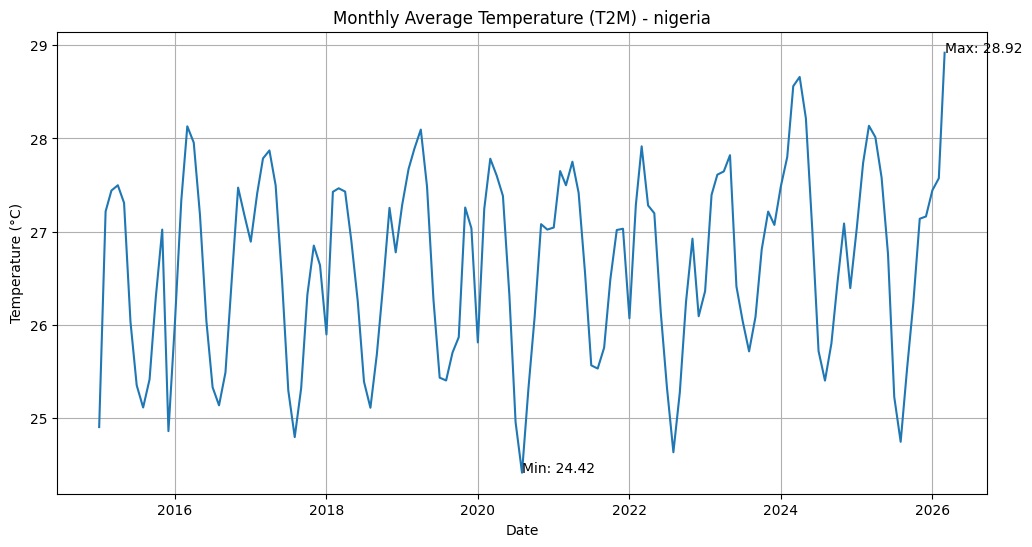

In [153]:
# Monthly average temperature (T2M)
import matplotlib.pyplot as plt


monthly_temp = df.groupby([df["Date"].dt.to_period("M")])["T2M"].mean()

monthly_temp.index = monthly_temp.index.to_timestamp()

plt.figure(figsize=(12,6))
plt.plot(monthly_temp.index, monthly_temp.values)

plt.title("Monthly Average Temperature (T2M) - nigeria")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid()

max_temp = monthly_temp.max()
min_temp = monthly_temp.min()

max_date = monthly_temp.idxmax()
min_date = monthly_temp.idxmin()

plt.annotate(f"Max: {max_temp:.2f}", (max_date, max_temp))
plt.annotate(f"Min: {min_temp:.2f}", (min_date, min_temp))

plt.show()

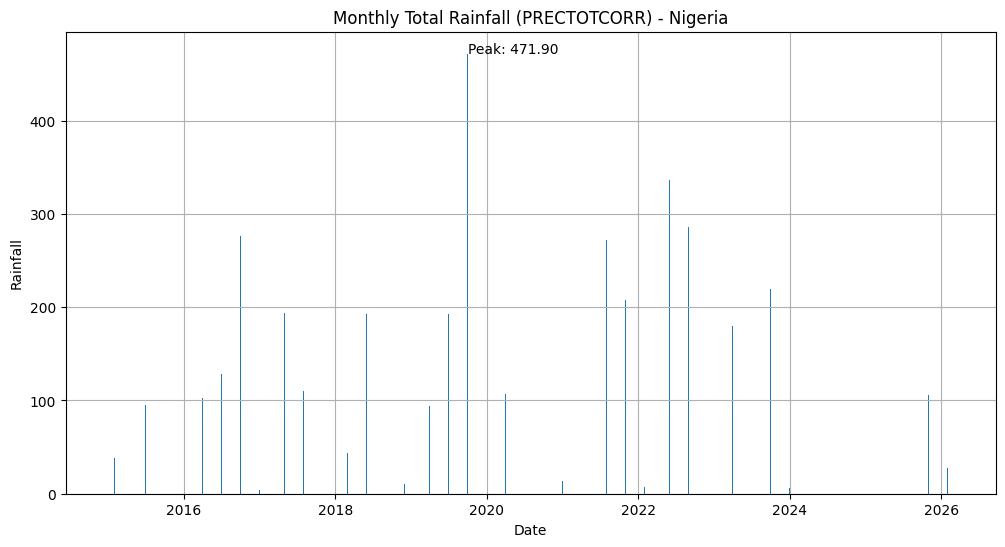

In [161]:
# Monthly total rainfall
monthly_rain = df.groupby([df["Date"].dt.to_period("M")])["PRECTOTCORR"].sum()
monthly_rain.index = monthly_rain.index.to_timestamp()

plt.figure(figsize=(12,6))
plt.bar(monthly_rain.index, monthly_rain.values)

plt.title("Monthly Total Rainfall (PRECTOTCORR) - Nigeria")
plt.xlabel("Date")
plt.ylabel("Rainfall")
plt.grid()

max_rain = monthly_rain.max()
max_rain_date = monthly_rain.idxmax()


plt.annotate(f"Peak: {max_rain:.2f}", (max_rain_date, max_rain))

plt.show()

### Interpretation

- The temperature trend shows **stable and consistent seasonal cycles**, typical of a **tropical climate**. Temperature variation is relatively small throughout the years, with no strong long-term increasing or decreasing trend.

- The **highest temperature** is observed around **2026**, reaching approximately **28.92°C**, indicating warm but not extreme conditions.

- The **lowest temperature** occurs around **2020**, dropping to about **24.42°C**, showing only mild seasonal cooling.

- Rainfall exhibits **strong seasonality with high variability**, with clear peaks during the rainy season and lower values during drier months.

- The **peak rainfall (~471.90 mm)** occurs around **2019–2020**, indicating a **very intense rainy season**, significantly higher than in semi-arid regions.

- Unlike dry climates, rainfall is **frequent and substantial across many periods**, not limited to rare events, although there are still relatively drier months.

### Overall Insight

The data reflects a **warm and humid tropical climate** with **low temperature variability and strong seasonal rainfall patterns**. Nigeria experiences **regular and intense rainy seasons**, distinguishing it from semi-arid regions, and indicating a **tropical wet climate with high precipitation levels**.

## 5. Correlation & Relationship Analysis

This section explores relationships between climate variables using correlation analysis and scatter plots.

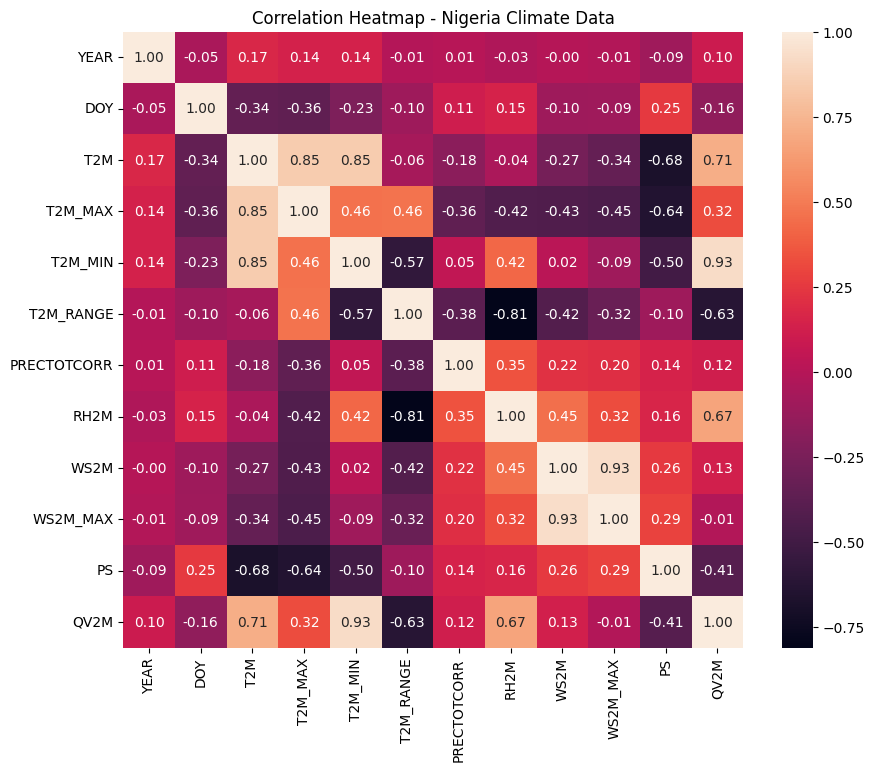

In [168]:
#Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt


numeric_df = df.select_dtypes(include=["float64", "int64"])


corr = numeric_df.corr()


plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f")

plt.title("Correlation Heatmap - Nigeria Climate Data")
plt.show()

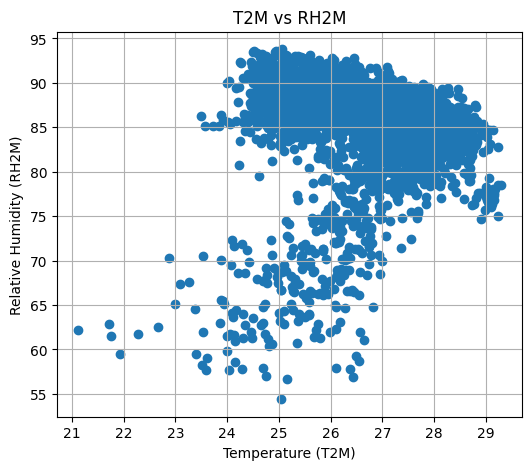

In [174]:
#Scatter Plot (T2M vs RH2M)
plt.figure(figsize=(6,5))
plt.scatter(df["T2M"], df["RH2M"])

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("T2M vs RH2M")

plt.grid()
plt.show()

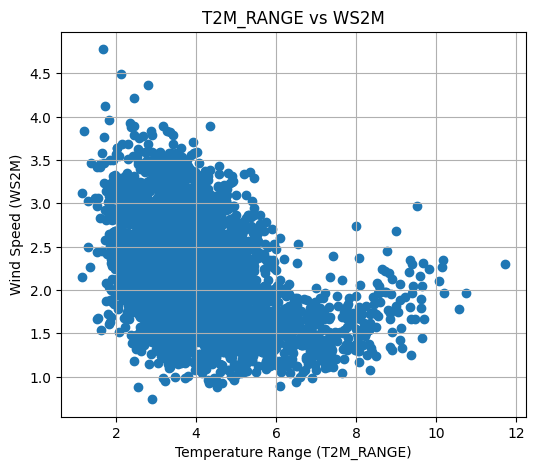

In [179]:
#Scatter Plot (T2M_RANGE vs WS2M)
plt.figure(figsize=(6,5))
plt.scatter(df["T2M_RANGE"], df["WS2M"])

plt.xlabel("Temperature Range (T2M_RANGE)")
plt.ylabel("Wind Speed (WS2M)")
plt.title("T2M_RANGE vs WS2M")

plt.grid()
plt.show()

### Correlation Interpretation

- There is a **strong positive correlation** between **T2M and T2M_MIN (≈ 0.85)** and **T2M and T2M_MAX (≈ 0.85)**. This indicates that average temperature is closely related to both minimum and maximum temperatures, though slightly weaker than in more extreme climates.

- A **strong negative correlation** exists between **T2M and surface pressure (PS) (≈ -0.68)**, suggesting that higher temperatures are associated with lower atmospheric pressure.

- A **very strong positive correlation** is observed between **WS2M and WS2M_MAX (≈ 0.93)**, confirming that average wind speed closely follows maximum wind speed behavior.

- A **strong negative correlation** exists between **T2M_RANGE and RH2M (≈ -0.81)**, indicating that larger temperature variations occur under lower humidity conditions.

- **Specific humidity (QV2M)** shows a **very strong positive correlation with T2M_MIN (≈ 0.93)** and a **strong positive correlation with RH2M (≈ 0.67)**, highlighting that moisture levels are closely tied to both humidity and minimum temperature.

- Rainfall (**PRECTOTCORR**) shows **weak to moderate positive relationships with humidity (≈ 0.35)** and **weak relationships with temperature**, indicating that rainfall is influenced more by atmospheric moisture than temperature alone.

### Scatter Plot Insights

- The **T2M vs RH2M plot** shows a **weak to moderate negative relationship**, but with noticeable clustering at high humidity levels (80–90%). This suggests that humidity remains generally high even as temperature varies.

- The **T2M_RANGE vs WS2M plot** shows a **weak and slightly negative relationship**, with wide dispersion. This indicates that wind speed has limited influence on temperature range.

### Overall Insight

Temperature variables remain **strongly interrelated**, while **humidity and moisture variables play a dominant role in rainfall patterns**. Compared to drier regions, Nigeria shows **consistently high humidity with weaker temperature-humidity coupling**, reflecting the characteristics of a **humid tropical climate**.

## 6. Distribution Analysis

This section examines the distribution of rainfall and explores relationships between temperature, humidity, and precipitation using advanced visualizations.

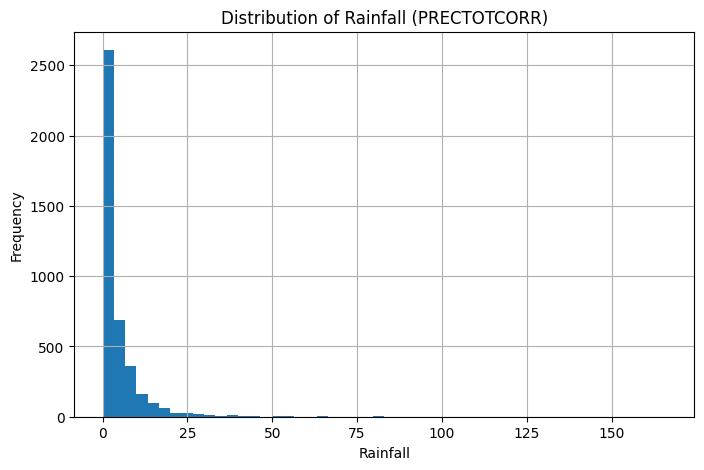

In [183]:
plt.figure(figsize=(8,5))

plt.hist(df["PRECTOTCORR"], bins=50)

plt.title("Distribution of Rainfall (PRECTOTCORR)")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")

plt.grid()
plt.show()

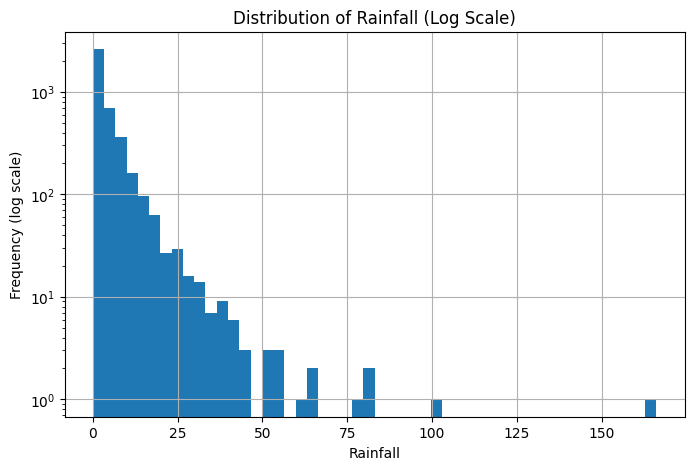

In [186]:
plt.figure(figsize=(8,5))

plt.hist(df["PRECTOTCORR"], bins=50)
plt.yscale("log")

plt.title("Distribution of Rainfall (Log Scale)")
plt.xlabel("Rainfall")
plt.ylabel("Frequency (log scale)")

plt.grid()
plt.show()

### Rainfall Distribution Interpretation

- The rainfall distribution is **strongly right-skewed**, with a high concentration of values at **low rainfall levels (near 0 mm)** and a long tail extending to **very high values (up to ~160+ mm)**.

- This indicates that while there are **many days with little or light rainfall**, there is also a **significant number of moderate rainfall events**, unlike dry regions where rainfall is mostly absent.

- The presence of extreme values highlights **occasional very intense rainfall events**, which are characteristic of tropical storm periods.

- Compared to semi-arid climates, the distribution shows a **wider spread of rainfall values**, suggesting more frequent precipitation across different intensities.

- When visualized on a **log scale**, the distribution reveals clearer patterns across **low, moderate, and high rainfall ranges**, showing that rainfall is not limited to rare extremes but occurs across multiple levels.

- Although frequency decreases as rainfall increases, the decline is **more gradual**, indicating that **moderate-to-heavy rainfall events are not uncommon**.

### Overall Insight

The distribution reflects a **humid tropical climate**, where rainfall is **frequent, varied in intensity, and includes occasional extreme events**. Unlike dry regions, precipitation is a **regular feature of the climate**, with both moderate and heavy rainfall contributing significantly to overall patterns.

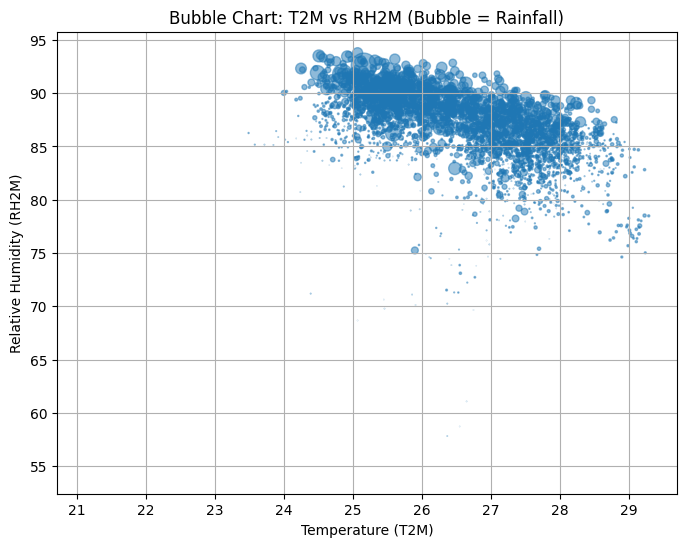

In [188]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["T2M"], 
    df["RH2M"], 
    s=df["PRECTOTCORR"] * 2,  # bubble size
    alpha=0.5
)

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("Bubble Chart: T2M vs RH2M (Bubble = Rainfall)")

plt.grid()
plt.show()

### Bubble Chart Interpretation

This analysis explores the interplay between surface temperature (T2M), relative humidity (RH2M), and precipitation levels (Rainfall) based on the generated bubble chart.

---

## Key Observations

### A. Temperature vs. Humidity Correlation
- There is a **negative linear trend** observed between Temperature ($T2M$) and Relative Humidity ($RH2M$). 
- As temperatures rise from **24°C toward 29.5°C**, the humidity levels generally shift downward.
- The data is most dense between **25°C and 28°C**, representing the core climatic state of the dataset.

### B. Rainfall Distribution (Bubble Magnitude)
- **Primary Driver:** The size of the bubbles (Rainfall) increases significantly as Relative Humidity exceeds **85%**.
- **The "Dry" Limit:** Below **80% humidity**, rainfall events become negligible, represented by microscopic points regardless of the temperature.
- **Optimal Precipitation Zone:** The largest rainfall events are clustered in the high-moisture/moderate-temperature window (approx. **25°C–27°C** and **>90% RH**).

---

## 3. Statistical Summary Table

| Variable | Observation Range | High Rainfall Condition |
| :--- | :--- | :--- |
| **Temperature (T2M)** | 24.0°C – 29.5°C | 25.0°C – 27.0°C |
| **Relative Humidity (RH2M)** | 55% – 94% | 88% – 94% |
| **Rainfall (Bubble Size)** | Highly Variable | Positively correlated with RH2M |

---

## 4. Climatic Insights
> **Note:** Contrary to previous semi-arid classifications, the high concentration of data points above **85% humidity** strongly suggests a **Tropical or Humid Maritime climate**.

* **Humidity Mediation:** Humidity acts as the primary gatekeeper for precipitation. Even at "favorable" temperatures, rainfall does not trigger unless the air is near saturation.
* **Inverse Sensitivity:** The downward slope of the bubble cluster confirms that while higher temperatures can hold more moisture, they are associated with lower *relative* humidity in this specific environment, which can paradoxically lead to less frequent heavy rainfall at the highest temperature extremes (29°C+).

---

## 5. Conclusion
The bubble chart effectively demonstrates that **atmospheric moisture (RH2M)** is a more reliable predictor of rainfall volume than **surface temperature** alone. For predictive modeling, humidity features should be prioritized as the leading indicator for precipitation events.

## References

- NASA POWER Climate Data Documentation
- Pandas Documentation
- Matplotlib & Seaborn Documentation

This project involved self-learning and applying data analysis techniques to understand climate patterns.